# 第 10 天：公开榜挑战

把策略提交到 public-test，生成可审核的 benchmark 结果。

今天模拟公开榜：每个团队提交轨迹和 manifest，教师或维护者用统一协议验证并发布结果。


In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "notebooks" / "tutorials"))

tu = importlib.import_module("tutorial_utils")

pd.set_option("display.precision", 4)
OUTPUT_DIR = tu.ensure_output(10)
print("project root:", ROOT)
print("output dir:", OUTPUT_DIR)

project root: D:\Projects\ChemWorld
output dir: D:\Projects\ChemWorld\runs\tutorials\day10


## 今日任务

请先运行顶部导入单元，确认 kernel 指向项目虚拟环境；随后按顺序执行每个代码单元，观察表格、图形和验证结果，并在最后写下自己的实验判断。


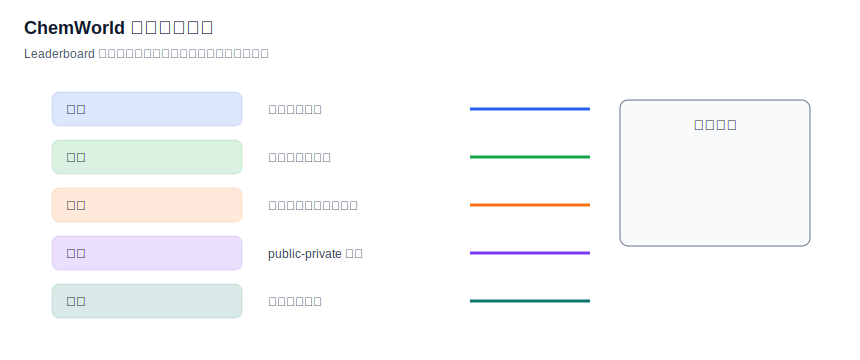

In [2]:
tu.display_tutorial_header(
    day=10,
    title='公开榜挑战',
    subtitle='把策略提交到 public-test，生成可审核的 benchmark 结果。',
    focus=[
        'submission trajectories',
        'public-test',
        'leaderboard rows',
        'strategy comparison',
    ],
    deliverables=[
        '一份 public submission',
        '一份评测结果表',
        '一份 replay 证明',
    ],
    project_link='公开榜用于开发和调试；最终结论必须等待 private evaluation。',
)
tu.display_course_map(10)
display(tu.leaderboard_blueprint_svg())


In [3]:
tu.display_api_card()

## 第 10 天检查点

完成本 notebook 后，请确认你已经留下这些证据：

- 一份合法 JSONL submission
- 一张 evaluation 结果表
- 一个 replay verification 结果
- 一行 public leaderboard 记录


In [5]:
strategies = {
    "conservative": {
        "temperature": 65.0,
        "time": 0.75,
        "initial_concentration": 0.25,
        "stirring_speed": 600.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "balanced": {
        "temperature": 75.0,
        "time": 0.50,
        "initial_concentration": 0.35,
        "stirring_speed": 650.0,
        "catalyst": 1,
        "solvent": 1,
    },
    "aggressive": {
        "temperature": 110.0,
        "time": 0.30,
        "initial_concentration": 0.60,
        "stirring_speed": 900.0,
        "catalyst": 3,
        "solvent": 2,
    },
}
pd.DataFrame(
    [{"strategy": name, **tu.format_recipe(recipe)} for name, recipe in strategies.items()]
)

,strategy,temperature_C,time_h,initial_concentration_M,stirring_rpm,catalyst,solvent
0,conservative,65.0,0.75,0.25,600.0,cat_b,ethanol
1,balanced,75.0,0.50,0.35,650.0,cat_b,ethanol
2,aggressive,110.0,0.30,0.60,900.0,cat_d,acetonitrile


,strategy,trajectory,verified,final_best_score,safety_aware_score,total_score
0,conservative,D:\Projects\ChemWorld\runs\tutorials\day10\con...,True,0.4785,0.4644,0.3760
1,balanced,D:\Projects\ChemWorld\runs\tutorials\day10\bal...,True,0.4691,0.4534,0.3682
2,aggressive,D:\Projects\ChemWorld\runs\tutorials\day10\agg...,True,0.2823,0.2530,0.2176


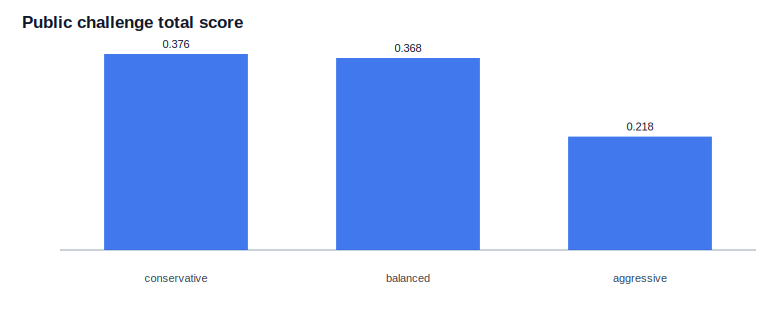

In [6]:
from chemworld.eval.metrics import evaluate_records
from chemworld.eval.verify import verify_records

submission_rows = []
for name, recipe in strategies.items():
    path = OUTPUT_DIR / f"{name}_public_submission.jsonl"
    records = tu.write_recipe_trajectory(
        recipe, path, split="public-test", seed=1000, agent_name=f"public_{name}"
    )
    evaluation = evaluate_records(records).to_dict()
    verification = verify_records(records).to_dict()
    submission_rows.append(
        {
            "strategy": name,
            "trajectory": str(path),
            "verified": verification["verified"],
            "final_best_score": evaluation["final_best_score"],
            "safety_aware_score": evaluation["safety_aware_score"],
            "total_score": evaluation["total_score"],
        }
    )
submissions_df = (
    pd.DataFrame(submission_rows).sort_values("total_score", ascending=False).reset_index(drop=True)
)
display(submissions_df)
display(
    tu.bar_svg(
        submissions_df["strategy"].tolist(),
        submissions_df["total_score"].astype(float).tolist(),
        title="Public challenge total score",
        color="#2563eb",
    )
)

In [7]:
challenge_rules = {
    "allowed_split": "public-test",
    "required_files": ["trajectory JSONL", "agent manifest or strategy note", "explanation"],
    "verification": "verify_records must return verified=True",
    "warning": "Do not tune only for public-test. Day 11 will check private-eval transfer.",
}
tu.show_json_panel("Public challenge rules", challenge_rules)

## 课后反思

请用两三句话回答下面的问题，并把答案写进当天的实验日志。


In [8]:
tu.display_reflection_box(
    [
        '什么行为会在 public-test 上过拟合？',
        '你会怎样设计防刷榜规则？',
    ]
)
